# Introduction

This notebook presents an analysis of the Vispubdata dataset, a comprehensive collection of metadata on publications from the IEEE Visualization (IEEE VIS) conferences spanning from 1990 to 2024. The dataset encompasses information on papers presented at IEEE VIS, as well as articles from the IEEE Transactions on Visualization and Computer Graphics (TVCG) and IEEE Computer Graphics and Applications (CG&A) that were presented at IEEE VIS. Each entry includes details such as the paper's title, authors, DOI, and citations to other VIS papers.

By analyzing this dataset, we aim to uncover trends and patterns in the field of visualization research, such as publication frequencies, collaboration networks, and citation behaviors. This exploration will provide insights into the evolution of the visualization community and its scholarly contributions over the past three decades.

# About IEEE VIS
**IEEE VS** is the flagship conference for the visualization field, sponsored by the IEEE Computer Society´s Visualization and Graphics Technical Committee (VGTC). It includes three main sub-conferences:
- **IEEE InfoVis** – Information Visualization
Focuses on the visualization of abstract data like networks, hierarchies, or multivariate data.
- **IEEE SciVis** – Scientific Visualization
Covers visualization techniques for data from the physical sciences (e.g., fluid dynamics, astrophysics, or medical imaging).
- **IEEE VAST** – Visual Analytics Science and Technology
Deals with analytical reasoning supported by interactive visual interfaces.

# Data Dictionary

**Conference:** Short title of the conference the paper appeared in. One of {SciVis, InfoVis, VAST, Vis}.
- **Year:** the year the paper appeared at the conference (note that this can be different from the year the paper has been published as, for example, most VIS 2018 papers were published in the first 2019 issue of the TVCG journal).
- **Title:** the title of the paper.
- **DOI:** if we found it, a DOI to the paper. Where a paper did not include a valid DOI (2 cases at this point), a syntactically valid but fake DOI was entered that starts with 10.0000. This column can, thus, be used as a unique identifier for each paper.
- **Link:** a link to the paper in the IEEE digital library - based on the DOI.
- **First Page:** the first page of the paper in the printed proceedings. This information has not been thoroughly checked for correctness.
- **Last Page:** the last page of the paper in the printed proceedings. This information has not been thoroughly checked for correctness.
- **PaperType:** one of C (conference paper), J (journal paper), M (miscellaneous). If you would like to filter for scientific research articles, then take all Cs and Ts. Papers with an "M" are not typically considered archival publications.
- **Abstract:** the abstract of the paper.
- **AuthorNames-Deduped:** co-authors are separated by a semicolon. Authors are ordered by how they appear on the paper. The full author names were taken from the de-duped names the DBLP provides.
- **Authors:** author names as they appeared on the paper. Currently this column is not yet complete. For analysis you should always use column AuthorNames-Deduped.
- **AuthorAffiliation:** author affiliation. This information has not been cleaned up and for most entries just shows the affiliation of the first author. This information has not been thoroughly checked for correctness.
- **InternalReferences:** a list of internal references to other IEEE VIS papers using DOIs of the papers in this list. This list does not include citations to papers external to this conference series. These internal citations are automatically extracted from a full-text extraction of the citation data using Grobid - therefore errors may have occurred.
- **AuthorKeywords:** a list of author keywords freely chosen by the authors - extracted as found on the paper pdf.
- **AminerCitationCount:** a number indicating how many times this publication has been cited. The citation count was extracted from the Aminer dataset (DBLP-Citation-network V14). The title of the column indicates the last time this count has been updated. A missing value indicates that this publication was not found in the Aminer dataset.
- **CitationCount_CrossRef:** a number indicating how many times this publication has been cited. This citation count was extracted from CrossRef. A missing value indicates that the article was not found on CrossRef.
- **PubsCited:** a number indicating a reference count = the number of other papers this publication cites. This is also automatically extracted via the CrossRef API.
- **Award:** a code indicating any VIS internal award the publication has won. BP = best paper, HM = best paper honorable mention (= like a runner-up), TT = test of time award (=an award for a paper that has proved to be influential to the community over time), BA=best application paper award,BCS=best case study award. The data for BP and HM is reliable from about 2004 for InfoVis and 2009 for Vis. Historic records on awards in early years is very sparse (e.g. comes from people's personal websites or CVs). TT awards are a recent addition to the conference, and therefore, complete.


# Imports

In [1]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt
import networkx as nx
from collections import Counter
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# Setup

In [2]:
plt.rcParams['figure.figsize'] = (14,4)
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['figure.frameon'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams["font.family"] = "monospace"
sns.set()

# Get Data

In [3]:
data = pd.read_csv('/kaggle/input/publication-dataset/IEEE VIS papers 1990-2023 - Main dataset.csv')
data.head()

,Conference,Year,Title,DOI,Link,FirstPage,LastPage,PaperType,Abstract,AuthorNames-Deduped,AuthorNames,AuthorAffiliation,InternalReferences,AuthorKeywords,AminerCitationCount,CitationCount_CrossRef,PubsCited_CrossRef,Downloads_Xplore,Award,GraphicsReplicabilityStamp
0,Vis,2023,Design Patterns for Situated Visualization in ...,10.1109/tvcg.2023.3327398,http://dx.doi.org/10.1109/TVCG.2023.3327398,1324.0,1335.0,J,Situated visualization has become an increasin...,Benjamin Lee;Michael Sedlmair;Dieter Schmalstieg,Benjamin Lee;Michael Sedlmair;Dieter Schmalstieg,"University of Stuttgart, Germany;University of...",10.1109/tvcg.2021.3114835;10.1109/tvcg.2020.30...,"Augmented reality,immersive analytics,situated...",NaN,11.0,124.0,736.0,NaN,NaN
1,Vis,2023,ggdist: Visualizations of Distributions and Un...,10.1109/tvcg.2023.3327195,http://dx.doi.org/10.1109/TVCG.2023.3327195,414.0,424.0,J,"The grammar of graphics is ubiquitous, providi...",Matthew Kay 0001,Matthew Kay,"Northwestern University, USA",10.1109/tvcg.2011.185;10.1109/tvcg.2014.234629...,"Uncertainty visualization,probability distribu...",NaN,7.0,55.0,281.0,NaN,NaN
2,Vis,2023,PromptMagician: Interactive Prompt Engineering...,10.1109/tvcg.2023.3327168,http://dx.doi.org/10.1109/TVCG.2023.3327168,295.0,305.0,J,Generative text-to-image models have gained gr...,Yingchaojie Feng;Xingbo Wang 0001;Kamkwai Wong...,Yingchaojie Feng;Xingbo Wang;Kam Kwai Wong;Sij...,"State Key Lab of CAD&CG, Zhejiang University, ...",10.1109/tvcg.2022.3209425;10.1109/tvcg.2006.18...,"Prompt engineering,text-to-image generation,im...",NaN,5.0,78.0,1065.0,NaN,NaN
3,Vis,2023,Challenges and Opportunities in Data Visualiza...,10.1109/tvcg.2023.3327378,http://dx.doi.org/10.1109/TVCG.2023.3327378,649.0,660.0,J,This paper is a call to action for research an...,Benjamin Bach;Mandy Keck;Fateme Rajabiyazdi;Ta...,Benjamin Bach;Mandy Keck;Fateme Rajabiyazdi;Ta...,"University of Edinburgh, United Kingdom;Univer...",10.1109/tvcg.2022.3209402;10.1109/tvcg.2022.32...,"Data Visualization,Education,Challenges",NaN,5.0,138.0,563.0,NaN,NaN
4,Vis,2023,Affective Visualization Design: Leveraging the...,10.1109/tvcg.2023.3327385,http://dx.doi.org/10.1109/TVCG.2023.3327385,1.0,11.0,J,"In recent years, more and more researchers hav...",Xingyu Lan;Yanqiu Wu 0001;Nan Cao 0001,Xingyu Lan;Yanqiu Wu;Nan Cao,"Fudan University, Research Group of Computatio...",10.1109/tvcg.2021.3114775;10.1109/tvcg.2020.30...,"Information Visualization,Affective Design,Vis...",NaN,4.0,95.0,848.0,BP,NaN


In [4]:
print(data.shape)
colors = sns.color_palette("icefire", as_cmap=False)
cmap = LinearSegmentedColormap.from_list("icefire", colors)
data.describe().style.background_gradient(cmap=cmap)

(3753, 20)


,Year,FirstPage,LastPage,AminerCitationCount,CitationCount_CrossRef,PubsCited_CrossRef,Downloads_Xplore
count,3753.000000,3702.000000,3487.000000,3443.000000,3752.000000,3752.000000,3747.000000
mean,2008.557687,688.627499,732.283912,79.117920,30.609808,33.075160,781.387510
std,9.014466,715.521960,727.673658,143.970048,62.459688,22.682471,1182.513418
min,1990.000000,1.000000,1.000000,0.000000,0.000000,0.000000,5.000000
25%,2002.000000,157.000000,181.000000,14.000000,5.000000,16.000000,163.000000
50%,2009.000000,396.500000,450.000000,41.000000,15.000000,29.000000,479.000000
75%,2016.000000,1042.500000,1109.500000,92.000000,36.000000,47.000000,973.000000
max,2023.000000,2946.000000,5186.000000,3795.000000,2061.000000,195.000000,27481.000000


In [5]:
paper_type_map = {
    'C': 'Conference',
    'J': 'Journal',
    'M': 'Miscellaneous'
}
data['PaperType'] = data['PaperType'].map(paper_type_map)

# Venues
The scatterplot below provides a clear overview of the publication trends across the visualization conferences over time. In total we have 3753 papers coming from 4 conferences organized by the IEEE. We can clearly see that they overlap in time. Since 2021, all the conferences have finally merged under the unique name VIS. By representing the number of papers as bubble sizes, it becomes easy to spot fluctuations in research activity and compare the relative prominence of each venue in different years. The visualization highlights both the temporal dynamics of the field and the varying contributions of individual conferences, offering insight into how the landscape of visualization research has evolved.

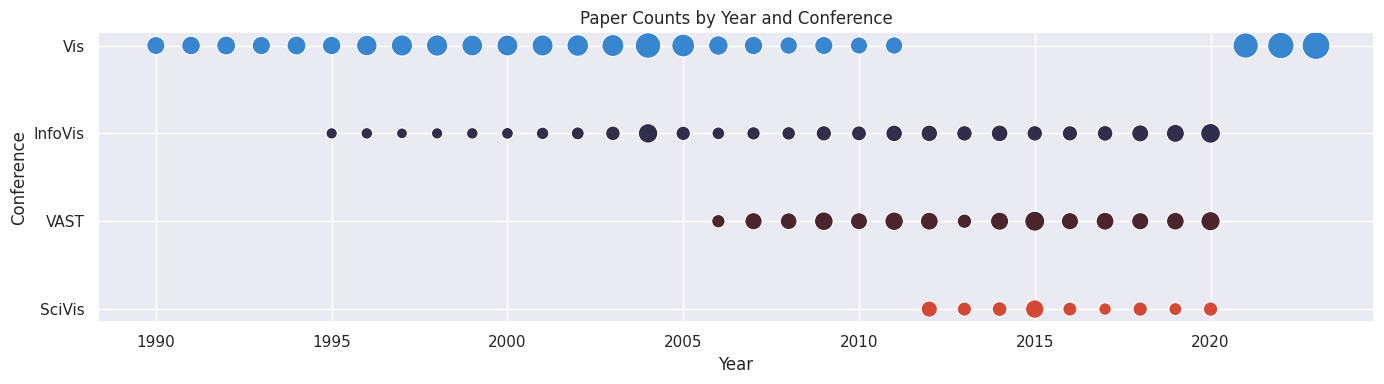

In [6]:
grouped = data.groupby(['Year', 'Conference']).size().reset_index(name='Count')
conference_order = ["Vis", "InfoVis", "VAST", "SciVis"]

sns.scatterplot(
    data=grouped,
    x='Year',
    y='Conference',
    size='Count',
    sizes=(60, 400),  
    hue='Conference',
    palette='icefire',
    legend=False
)

plt.ylabel('Conference')
plt.xlabel('Year')
plt.title('Paper Counts by Year and Conference')
plt.tight_layout()
plt.show()

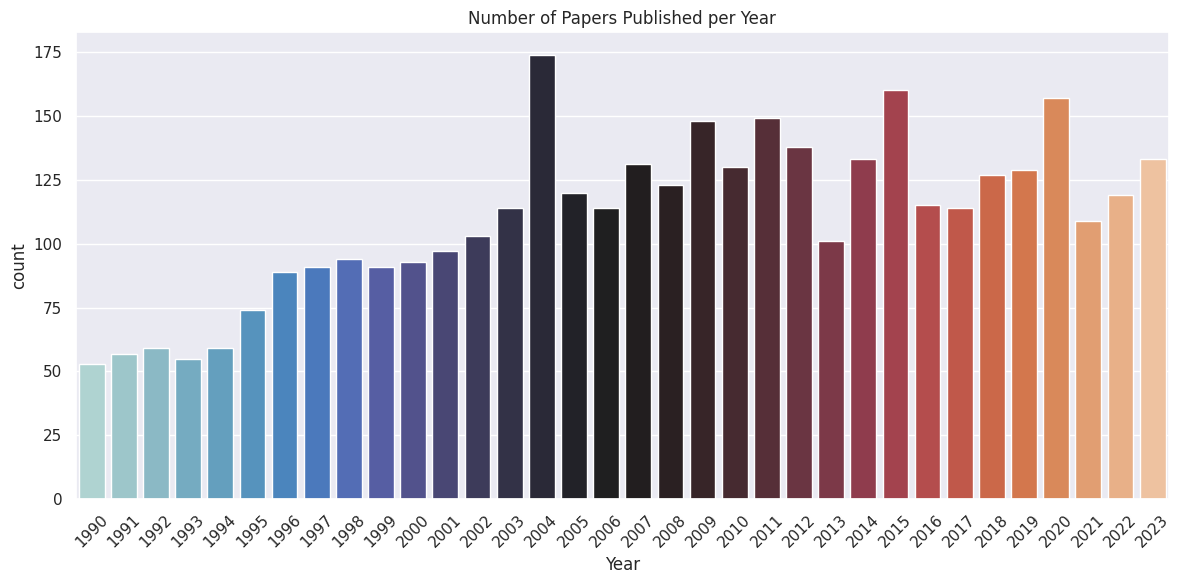

In [7]:
plt.figure(figsize=(12, 6))
sns.countplot(data=data, x='Year', order=sorted(data['Year'].dropna().unique()), palette='icefire')
plt.xticks(rotation=45)
plt.title('Number of Papers Published per Year')
plt.tight_layout()
plt.show()

This plot illustrates the trend in the volume of papers published each year, offering a clear snapshot of the overall research activity in the field of visualization. By tracking the number of papers per year, it reveals periods of growth, stability, or decline, providing valuable context for understanding the momentum and evolution of visualization research over time.

# Autors
This plot is crucial for publication analysis as it visually captures the relationship between the number of coauthors and the types of papers being published. By examining the distribution of papers across varying levels of collaboration, it provides insights into trends in authorship, such as whether certain types of papers tend to have more collaborators than others. This can reveal patterns in research practices, such as whether interdisciplinary or large-scale studies are more common in particular paper types, or if the complexity of the research influences the number of coauthors. Additionally, understanding these trends can highlight shifts in academic collaboration over time, offering a valuable perspective for researchers, institutions, and funding bodies interested in promoting effective collaboration or understanding the dynamics of modern scholarly work.

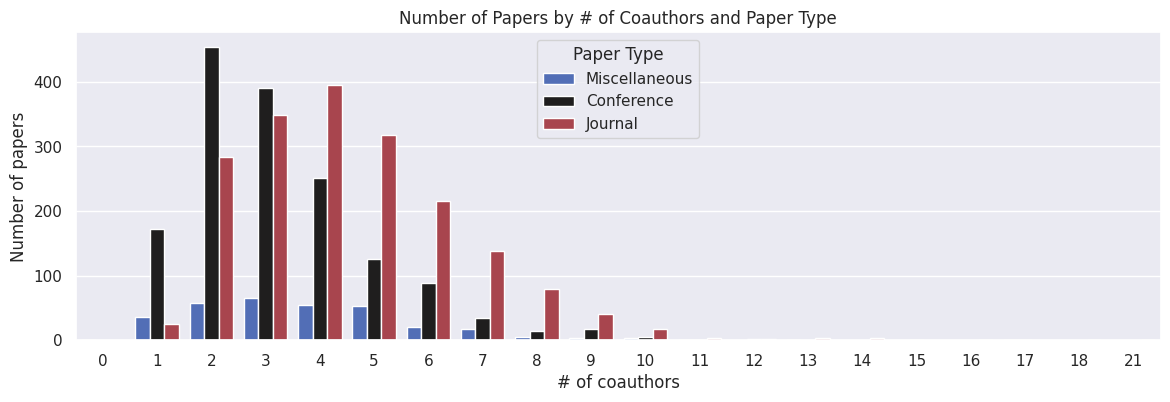

In [8]:
data['NumCoauthors'] = data['AuthorNames'].apply(lambda x: len(x.split(';')) if isinstance(x, str) else 0)
grouped = data.groupby(['NumCoauthors', 'PaperType']).size().reset_index(name='Count')
pivot = grouped.pivot(index='NumCoauthors', columns='PaperType', values='Count').fillna(0)
sns.barplot(data=grouped, x='NumCoauthors', y='Count', hue='PaperType', palette='icefire')
plt.xlabel('# of coauthors')
plt.ylabel('Number of papers')
plt.title('Number of Papers by # of Coauthors and Paper Type')
plt.legend(title='Paper Type')
plt.show()

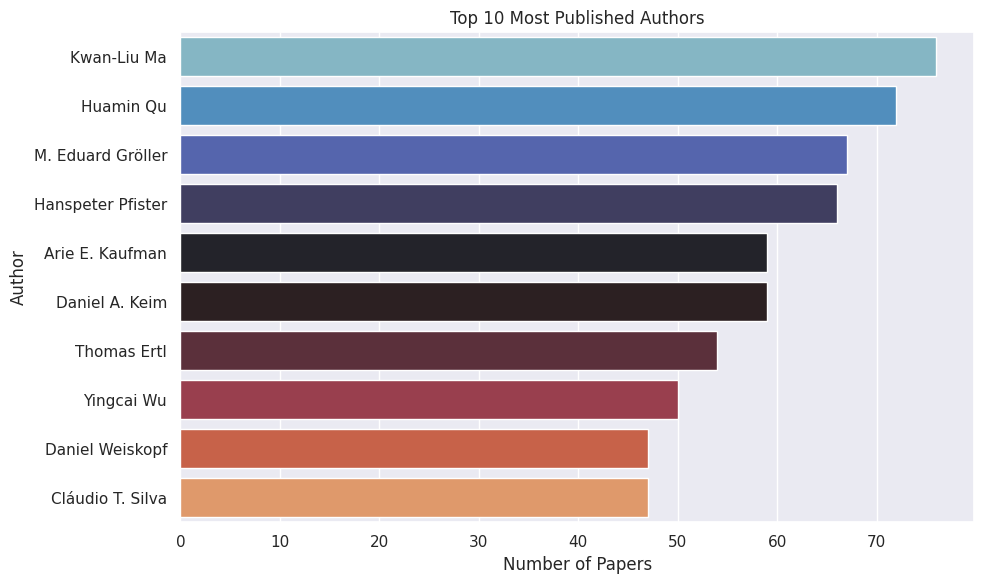

In [9]:
authors = data['AuthorNames-Deduped'].dropna().str.split(';').explode().str.strip()
top_authors = authors.value_counts().head(10).reset_index()
top_authors.columns = ['Author', 'PaperCount']
plt.figure(figsize=(10, 6))
sns.barplot(data=top_authors, y='Author', x='PaperCount', palette='icefire')
plt.title('Top 10 Most Published Authors')
plt.xlabel('Number of Papers')
plt.ylabel('Author')
plt.tight_layout()
plt.show()

This plot is essential for analyzing the most prolific authors in a given dataset, providing a clear representation of the top 10 individuals who have contributed the most to the research output. By visualizing the number of papers published by each of these authors, the chart allows for a quick identification of leading scholars in the field. Understanding who the top authors are can offer valuable insights into trends of expertise, collaboration, and influence within the research community. It can also help identify potential thought leaders or experts whose work may have shaped the field significantly. This analysis is particularly useful for institutions, researchers, and policymakers aiming to recognize high-impact contributors or for assessing the productivity of authors in specific areas of study.

# Citation

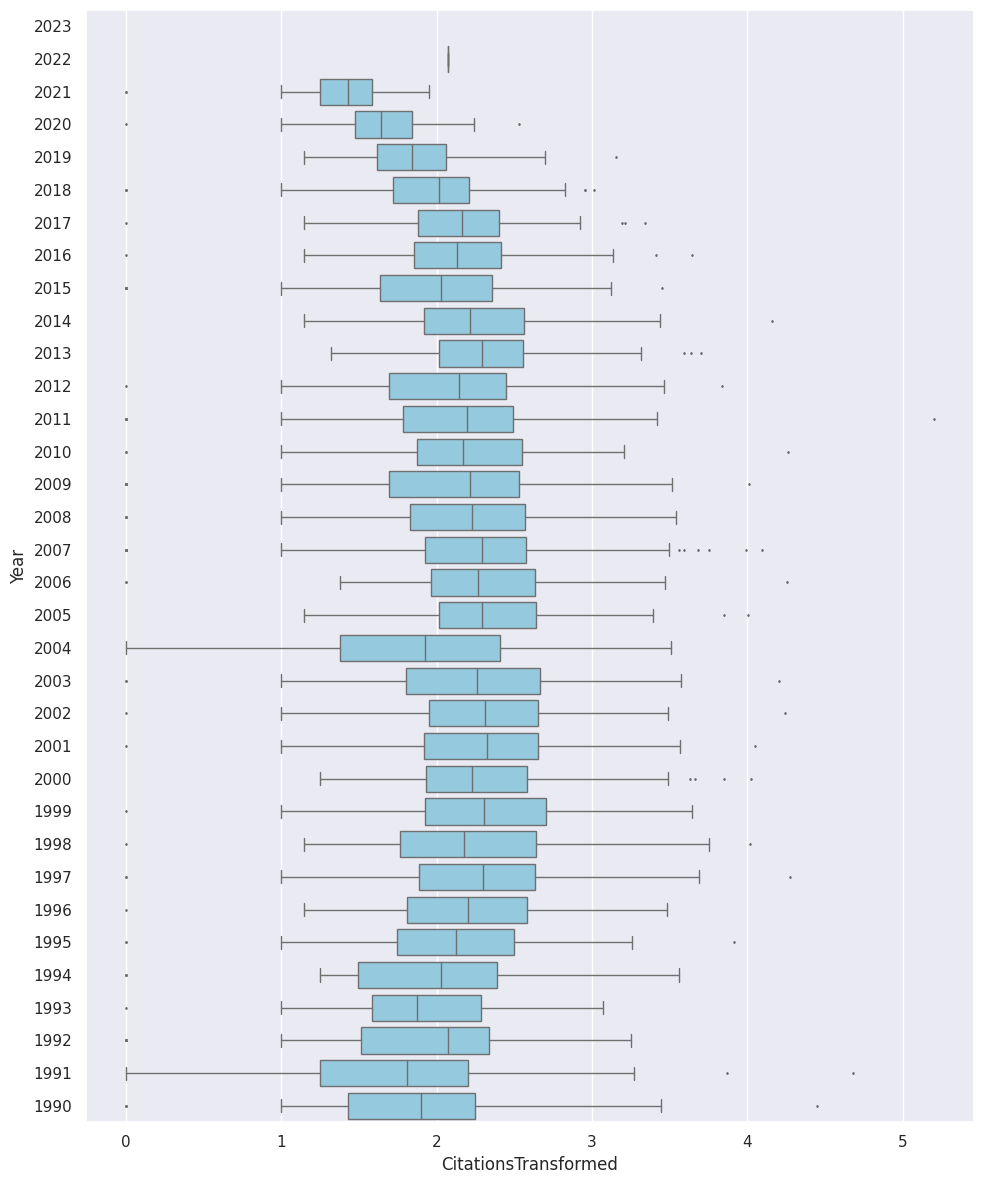

In [10]:
pow_exponent = 0.2 
data['CitationsTransformed'] = data['AminerCitationCount'].clip(lower=0).pow(pow_exponent)


plt.figure(figsize=(10, 12))
sns.boxplot(
        data=data,
        x='CitationsTransformed',
        y='Year',
        orient='h',
        color='skyblue',
        linewidth=1,
        fliersize=1
    )

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

This plot is essential for visualizing how citation counts are distributed across all publication years, using a power transformation to reveal more structure in the data. Applying an exponential scaling to citation values compresses the long tail of highly cited papers and enhances visibility of the dense middle portion of the distribution, where most publications lie. The result is a more interpretable and balanced view of citation behavior over time, making it easier to identify years with greater variability, consistent medians, or notable outliers. This approach is especially useful when dealing with heavily skewed data, as is common in citation analysis, and provides a clearer picture of the overall scholarly impact pattern without distorting key trends.


*(Note that we had to skew the x axis with an exponent in order to show more “meat” of the data. This doesn’t fundamentally alter the analysis, but it will select more or less points as outliers.)*

# Citation Network

In [11]:
data = data.dropna(subset=['Year', 'AminerCitationCount']).copy()
data = data.reset_index(drop=True)

data['Year'] = data['Year'].astype(int)
data['cited'] = data['AminerCitationCount'].fillna(0).astype(int).clip(lower=1)

jitter_strength = 0.2
data['x'] = data['cited']
data['y'] = data['Year'] + np.random.uniform(-0.25, 0.25, size=len(data))
doi_index = {str(row['DOI']).strip(): i for i, row in data.iterrows()}


G = nx.DiGraph()
for i, row in data.iterrows():
    G.add_node(i,
               x=row['x'],
               y=row['y'],
               title=row.get('Title', 'N/A'),
               authors=row.get('AuthorNames', 'N/A'),
               conference=row.get('Conference', 'Unknown'),
               papertype=row.get('PaperType', 'Unknown'))

for i, row in data.iterrows():
    if pd.notna(row['InternalReferences']):
        for ref in str(row['InternalReferences']).split(";"):
            ref_doi = ref.strip()
            j = doi_index.get(ref_doi)
            if j is not None:
                G.add_edge(i, j)


positions = {n: (G.nodes[n]['x'], G.nodes[n]['y']) for n in G.nodes}

color_by = 'Conference'
categories = sorted(set(G.nodes[n].get(color_by.lower(), 'Unknown') for n in G.nodes))
color_map = plt.get_cmap('plasma')

category_to_color = {
    cat: f'rgb{tuple((np.array(color_map(i / max(1, len(categories)-1))[:3]) * 255).astype(int))}'
    for i, cat in enumerate(categories)
}

node_colors = [category_to_color[G.nodes[n].get(color_by.lower(), 'Unknown')] for n in G.nodes]


edge_x, edge_y = [], []
for src, dst in G.edges:
    x0, y0 = positions[src]
    x1, y1 = positions[dst]
    edge_x += [x0, x1, None]
    edge_y += [y0, y1, None]

node_x = [positions[n][0] for n in G.nodes]
node_y = [positions[n][1] for n in G.nodes]
hover_text = [
    f"Title: {G.nodes[n]['title']}<br>Authors: {G.nodes[n]['authors']}<br>Year: {G.nodes[n]['y']}<br>Citations: {G.nodes[n]['x']:.1f}"
    for n in G.nodes
]

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    mode='lines',
    showlegend=False,
    line=dict(width=0.5, color='gray'),
    hoverinfo='none'
)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    text=hover_text,
    showlegend=False, 
    marker=dict(
        size=8,
        color=node_colors,
        opacity=0.85,
        line=dict(width=0.5, color='black')
    )
)


# horizontal lines
year_lines = []
for year in sorted(data['Year'].unique()):
    year_lines.append(dict(
        type='line',
        xref='paper',
        yref='y',
        x0=0, x1=1,
        y0=year, y1=year,
        line=dict(color='lightgray', width=1, dash='dot')
    ))

# for conference legend
legend_traces = []
for conf, color in category_to_color.items():
    legend_traces.append(go.Scatter(
        x=[None], y=[None],  # invisible point
        mode='markers',
        marker=dict(size=10, color=color),
        name=conf,
        showlegend=True
    ))

fig = go.Figure(
    data=[edge_trace, node_trace] + legend_traces,
    layout=go.Layout(
        title="Citation Network",
        hovermode='closest',
        xaxis=dict(
            title='Citation Count',
            type='log',
            showgrid=True,
            zeroline=False,
            tickformat=','
        ),
        yaxis=dict(
            title='Publication Year',
            showgrid=True,
            tickmode='linear',
            dtick=1
        ),
        plot_bgcolor='white',
        margin=dict(l=40, r=40, t=60, b=50),
        height=2000,
        shapes=year_lines,
        legend=dict(
            title='Conference',
            itemsizing='constant',
            bgcolor='white',
            bordercolor='black',
            borderwidth=0.5
        )
    )
)
fig.show()

This plot is essential for examining the citation landscape of a research dataset, offering a comprehensive view of how papers are interconnected through references. By positioning each publication along a log-scaled citation axis and aligning it with its publication year, the chart enables quick identification of highly cited works and their temporal distribution. The addition of colored nodes based on conference affiliations provides further insight into where influential research is being published. Citation links between papers help uncover patterns of scholarly influence, revealing how knowledge propagates across time and venues. This analysis is particularly useful for researchers, evaluators, and decision-makers seeking to understand impact dynamics, recognize foundational works, or explore the evolution of research within and across specific conferences.
It´s a bit messy to read but we can clearly idenfiy the top paper of all time which is **“D³ Data Driven Documents,” by Michael Bostock, Vadim Ogievetsky and Jeffrey Heer, in 2011)**.

# Keywords

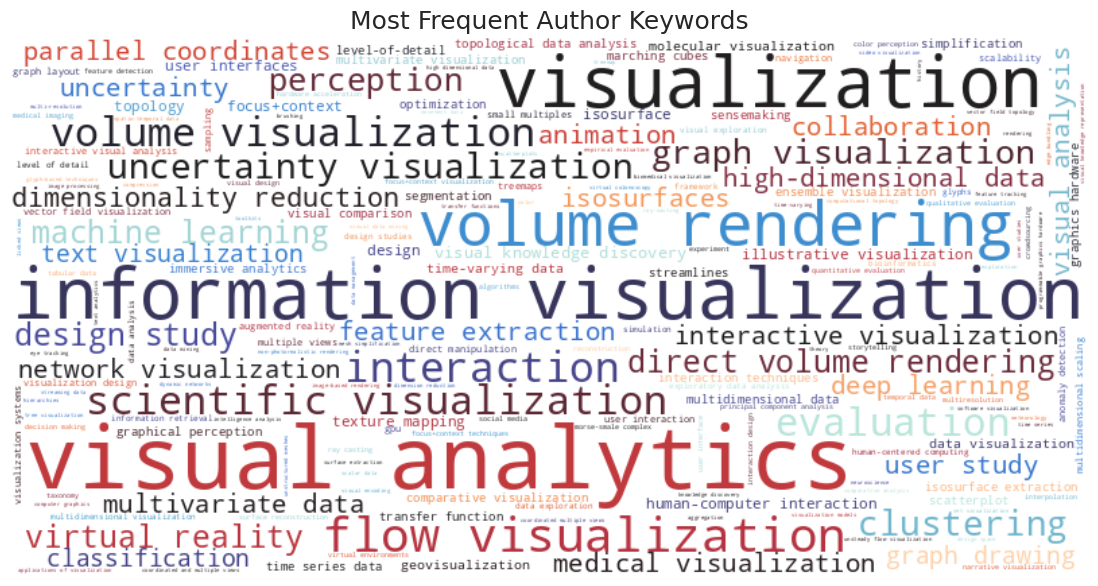

In [12]:
keywords = data['AuthorKeywords'].dropna().str.split(';|,').explode().str.strip().str.lower()
word_freq = Counter(keywords)

colors = sns.color_palette("icefire", as_cmap=True)
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    colormap='icefire'  # Fire-ice color style
).generate_from_frequencies(word_freq)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Author Keywords', fontsize=18)
plt.show()

This plot is essential for exploring the most frequently used author-provided keywords within a research dataset, offering a visually engaging summary of dominant themes and topics. By aggregating and visualizing keyword frequency through a word cloud, the chart highlights terms that appear most often across the dataset, with larger words representing higher occurrences. This makes it easy to identify prevailing areas of focus, emerging trends, and common research themes at a glance. The use of a vibrant color palette further enhances readability and draws attention to key terms. This analysis is particularly valuable for researchers, reviewers, and strategic planners aiming to map topical coverage, track evolving interests in the field, or guide future investigations based on current keyword usage patterns.